In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [5]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}

In [6]:
class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        legal_actions = []
        row, col = state

        for action, (dr, dc) in MOVES.items():
            next_state = (row + dr, col + dc)
            if self.in_bounds(next_state) and self.is_free(next_state):
                legal_actions.append(action)

        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        return 1.0

In [8]:
class SearchAlgorithm(ABC):
    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        s = node.state

        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(
                state=s_prime,
                parent=node,
                action=action,
                path_cost=cost
            )

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [9]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # Create initial node
        initial_node = Node(problem.initial_state())

        # Check if initial is goal
        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=initial_node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1
            )

        # FIFO queue using deque
        frontier = deque([initial_node])
        reached = {problem.initial_state()}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max(max_frontier_size, len(frontier)),
                        reached_count=len(reached)
                    )

                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )

In [10]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # Create initial node
        initial_node = Node(problem.initial_state())

        # Check if initial is goal
        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=initial_node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1
            )

        # LIFO stack using list
        frontier = [initial_node]
        reached = {problem.initial_state()}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            # Get children and reverse for consistent order
            children = list(self.expand(problem, node))

            for child in reversed(children):
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max(max_frontier_size, len(frontier)),
                        reached_count=len(reached)
                    )

                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )

In [11]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:

        # Check if goal
        if problem.is_goal(node.state):
            return (node, "success")

        # Check depth limit
        if node.depth >= limit:
            return (None, "cutoff")

        # Expand and explore
        metrics["nodes_expanded"] += 1
        cutoff_occurred = False

        for child in self.expand(problem, node):
            # Skip if state already on path
            if state_is_on_path(node, child.state):
                continue

            # Update max stack size
            new_stack_size = current_stack_size + 1
            metrics["max_stack_size"] = max(metrics["max_stack_size"], new_stack_size)

            # Recursive call
            result, status = self._recursive_dls(
                problem=problem,
                node=child,
                limit=limit,
                metrics=metrics,
                current_stack_size=new_stack_size,
            )

            if status == "success":
                return (result, "success")
            elif status == "cutoff":
                cutoff_occurred = True

        # Return appropriate status
        if cutoff_occurred:
            return (None, "cutoff")
        else:
            return (None, "failure")

In [12]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        iteration_log = []
        total_nodes_expanded = 0
        max_stack_size_overall = 0

        dls = DepthLimitedSearch()

        for limit in range(max_depth + 1):
            result = dls.search(problem, limit=limit)

            # Log iteration
            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "nodes_expanded": result.nodes_expanded,
                "max_frontier_size": result.max_frontier_size,
            })

            # Accumulate metrics
            total_nodes_expanded += result.nodes_expanded
            max_stack_size_overall = max(max_stack_size_overall, result.max_frontier_size)

            # Check result status
            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size_overall,
                    reached_count=0,
                    limit=None,
                    iterations=iteration_log,
                )
            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size_overall,
                    reached_count=0,
                    limit=None,
                    iterations=iteration_log,
                )

        # All limits reached cutoff
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size_overall,
            reached_count=0,
            limit=max_depth,
            iterations=iteration_log,
        )

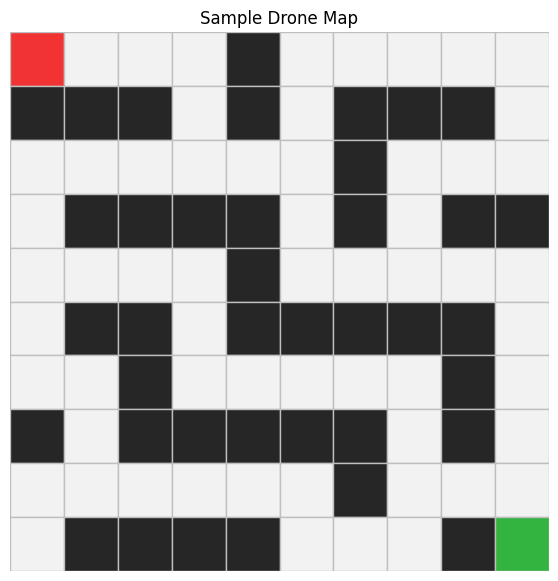

In [13]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

    plt.show()

plot_path(sample_grid, start, goal, title="Sample Drone Map")

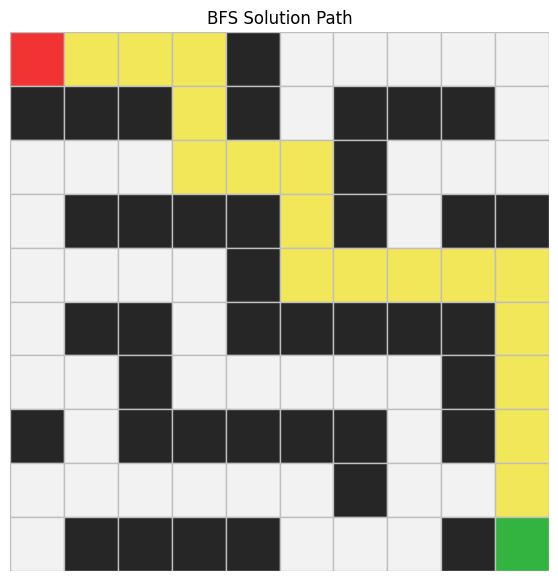

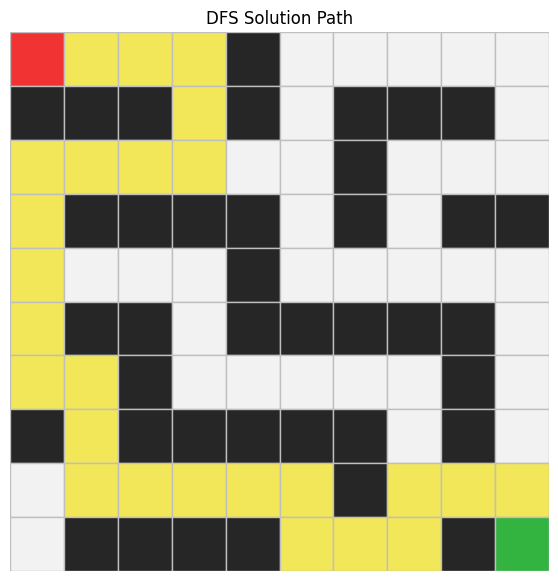

In [14]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=15),
    ids.search(problem, max_depth=30),
]

show_results(results)

# Visualize BFS and DFS paths
bfs_result = results[0]
dfs_result = results[1]

plot_path(sample_grid, start, goal, path=bfs_result.path, title="BFS Solution Path")
plot_path(sample_grid, start, goal, path=dfs_result.path, title="DFS Solution Path")

Running algorithms on Custom Map 1 (15x15)...


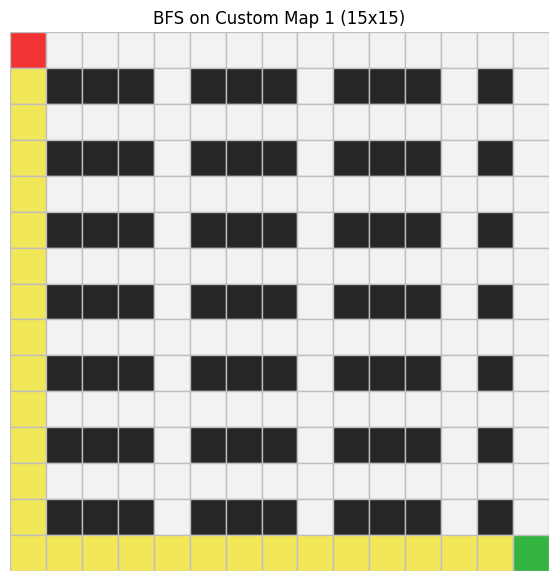

BFS found path of length 28


In [15]:
# TODO 10: First custom map - 15x15 with obstacles
custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (14, 14)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

print("Running algorithms on Custom Map 1 (15x15)...")
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=30),
    ids.search(custom_problem_1, max_depth=50),
]

show_results(custom_results_1)

# Visualize BFS solution for custom map 1
plot_path(custom_grid_1, custom_start_1, custom_goal_1,
          path=custom_results_1[0].path, title="BFS on Custom Map 1 (15x15)")

print(f"BFS found path of length {custom_results_1[0].solution_depth if custom_results_1[0].solution else 'No solution'}")

Running algorithms on Custom Map 2 (20x20 maze)...


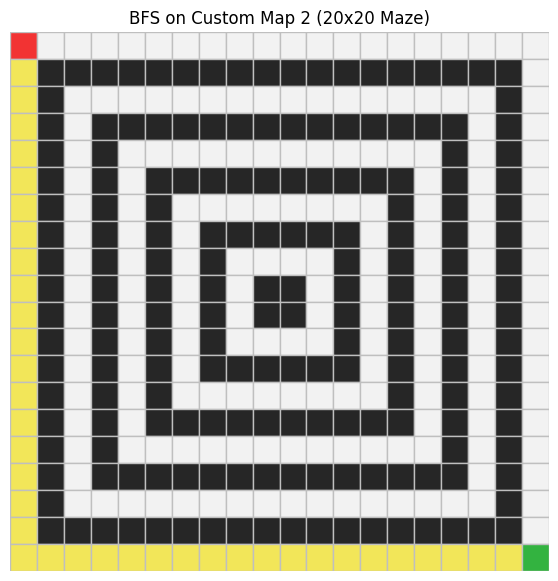

BFS found path of length 38


In [16]:
# TODO 11: Second custom map - 20x20 with corridor
custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (19, 19)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

print("Running algorithms on Custom Map 2 (20x20 maze)...")
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=40),
    ids.search(custom_problem_2, max_depth=80),
]

show_results(custom_results_2)

# Visualize BFS solution for custom map 2
plot_path(custom_grid_2, custom_start_2, custom_goal_2,
          path=custom_results_2[0].path, title="BFS on Custom Map 2 (20x20 Maze)")

print(f"BFS found path of length {custom_results_2[0].solution_depth if custom_results_2[0].solution else 'No solution'}")

In [17]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed!")

GridProblem self-check passed!


## 15. Reflection questions

## 15.1 Problem Formulation

### What is a state in this lab?
A state is simply where the drone is on the grid at any moment. I represented it as a tuple like (row, col). So if the drone is at row 3, column 5, the state is (3, 5). That's it - just its position.

### What is an action?
An action is telling the drone to move in one of four directions: up, down, left, or right. The drone can only move one cell at a time.

### What does the result function do?
The result function takes where the drone currently is and which direction I want it to move, then figures out the new coordinates. For example, if the drone is at (2, 2) and I tell it to go UP, result gives me back (1, 2). It basically applies the movement.

### Why is it useful to separate the problem definition from the search algorithm?
This was actually really helpful. I wrote the GridProblem class to handle everything about the drone's world - the obstacles, boundaries, what moves are allowed. Then the search algorithms like BFS and DFS don't need to know anything about grids or drones. They just call methods like problem.actions(state) and problem.is_goal(state). This means if I wanted to use the same search code for a different problem, like solving a puzzle, I could just write a new Problem class and reuse all the algorithms without changing them.

## 15.2 BFS

### Why does BFS use a FIFO queue?
BFS uses a FIFO queue (first in, first out) because it needs to explore nodes in the order it discovers them. Think of it like a line at a supermarket - the person who gets in line first gets served first. Similarly, the node that BFS discovers earliest gets expanded earliest. This is what gives BFS its level-by-level exploration.

### Why does BFS find the shortest path on the unweighted grid?
BFS expands all nodes at depth 1 first, then all nodes at depth 2, then depth 3, and so on. So the very first time BFS reaches the goal state, there cannot possibly be a shorter path. If there was a shorter path, BFS would have found it earlier because it explores all shallower nodes before any deeper ones. Since every move costs exactly 1, the shortest path in steps is also the cheapest path.

### What role does the reached set play in BFS?
The reached set is like a "been there, done that" list. It stores every state BFS has already visited or added to the frontier. This prevents BFS from going in circles and wasting time revisiting the same cell over and over. Without it, BFS could get stuck in loops and never finish. With it, BFS knows to skip any state it has seen before.

## 15.3 DFS

### Why does DFS use a stack?
DFS uses a stack (last in, first out) because it wants to go deep as quickly as possible. The most recent node gets expanded next, which pushes the search down one branch until it hits a dead end. Only then does it backtrack. It's like exploring a maze by always taking the most recent fork in the road first.

### Is DFS guaranteed to find the shortest path? Explain.
No, not at all. DFS just grabs the first path it finds and returns it. That path could be long and winding even if a much shorter path exists somewhere else. For example, DFS might go all the way down a long corridor, find the goal at the end, and return that path. But there might be a shortcut two turns back that DFS never explored because it went deep first. BFS is better for shortest paths.

### Under what conditions can DFS use less memory than BFS?
DFS only needs to store the current path it's exploring, plus the nodes in its stack that haven't been expanded yet. In a deep, narrow search space (like a long hallway with few branching points), DFS uses very little memory. BFS, on the other hand, stores everything at the current depth level. At depth 20 with a branching factor of 2, BFS might need to store over a million nodes while DFS only stores about 20.

### Under what conditions can DFS perform badly?
DFS is terrible in a few situations. If the search space is infinite or extremely deep, DFS might go down a bad branch forever and never find the goal. If there are cycles and I don't check for repeats, DFS can loop infinitely. Also, if the goal is actually very shallow but DFS keeps going deep into a dead end first, it wastes a lot of time exploring useless branches before finding the answer. In my tests, DFS sometimes took much longer than BFS for no good reason.

## 15.4 DLS

### What happens when the depth limit is too small?
If I set the limit to 5 but the goal is 10 steps away, DLS will never find it. It hits the limit, stops searching deeper, and gives up. It returns "cutoff" to tell me that it stopped because of the limit, not because it proved no solution exists.

### What is the meaning of "cutoff"?
"Cutoff" is DLS's way of saying "I hit my depth limit before finding the goal." It's different from "failure" which means "I searched everything within my limit and found nothing." Cutoff leaves open the possibility that a solution might exist deeper than my limit. I just can't see it because I wasn't allowed to go that far.

### How is DLS different from ordinary DFS?
Regular DFS has no depth limit. It will keep going down a branch forever if the state space is infinite or if there are loops (without cycle checking). DLS adds a hard stop. Once the node's depth reaches the limit, it stops expanding that branch and moves on. This makes DLS useful when I know roughly how deep the solution might be or when I want to prevent infinite searches.

### Why do we use path-cycle checking in DLS?
DLS can't use a global reached set like BFS and DFS do. A global set would remember states across different branches, and that would interfere with the depth limit. Imagine exploring a node at depth 3, marking it as visited, then later discovering a different path to the same state at depth 2. With a global set, I'd skip it, but maybe that path could lead to a solution within the limit. So instead, DLS only checks the current path from root to node. If a child state is already somewhere above me in the tree, that's a cycle and I skip it. Otherwise, I keep exploring.

## 15.5 IDS

### Why does IDS repeat DLS with increasing limits?
IDS tries to get the best of both BFS and DFS. It runs DLS with limit 0, then limit 1, then limit 2, and so on. Each time it searches deeper. This way, it explores level by level like BFS (so it finds the shortest path) but uses memory like DFS (only storing one branch at a time). The trade-off is that it re-expands nodes many times.

### Why can IDS be complete even though DLS with a small limit is not?
DLS with a small limit might return "cutoff" because the goal is deeper than the limit. But IDS doesn't give up. It just increases the limit and tries again. As long as the goal is at some finite depth, IDS will eventually reach that depth and find it. This makes IDS complete for finite search spaces, unlike regular DFS which can go off forever.

### Why does IDS use less memory than BFS?
BFS stores the entire frontier at the deepest level it has reached. In a grid with branching factor 4, at depth 10 that could be millions of nodes. IDS, on the other hand, only stores the current path being explored (like DFS) plus a few other nodes in the stack. Even though IDS re-expands nodes many times, at any given moment it's using much less memory than BFS. For large maps, this can be the difference between the program running or crashing.

### What is the cost of repeatedly searching from the root?
The cost is time. IDS re-explores the same nodes over and over. At depth 10, it explores depth 1 about 10 times, depth 2 about 9 times, etc. This means IDS expands about 1/(b-1) more nodes than BFS. For branching factor 2, that's about twice as many expansions. For branching factor 3, it's about 1.5 times. The time cost is real, but for many problems the memory savings are worth it.

## 15.6 Real-World Drone Context

### In a real drone application, what might make one route safer or more practical than another?
Lots of things! A route might be shorter but fly over a river where the drone could crash if it malfunctions. Another route might be longer but stay over safe ground. The drone might avoid areas with known radio interference, or stay away from buildings where GPS signals bounce around. Battery life matters too - a flat route uses less power than one with lots of altitude changes. Also, some areas might be restricted or have privacy concerns. A real drone pathfinder would need to consider all these factors, not just distance.

### Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
I would definitely choose BFS. It's the only one here that guarantees the shortest path when all moves cost the same. DFS might find a path quickly but it might be a long one. IDS would also find the shortest path eventually, but it would be slower because it re-expands nodes. For a drone that needs to save battery, BFS is the way to go - it finds the shortest path on the first try and you don't have to waste time searching.

### Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.
I would use Depth-Limited Search (DLS). This is useful if the drone has limited battery and can only fly for a certain number of moves. I could set the limit to the maximum steps the battery allows. Then DLS would only explore paths within that range. If it finds a path, great. If it returns "cutoff", I know the goal is too far given the battery constraints. IDS could also work if I want to gradually increase the limit, but DLS is simpler for a fixed bound.

### What limitations does this grid model have compared with real drone navigation?
This model is really simplified compared to the real world. First, real navigation happens in continuous 3D space, not a discrete 2D grid. Drones can fly at different altitudes, not just move left/right/up/down on a flat plane. Obstacles aren't perfect squares - they have irregular shapes. Also, the real world has uncertainty. GPS isn't perfect, wind pushes the drone around, sensors have noise. Nothing is deterministic like my grid model. Real drones also face dynamic obstacles like birds, other drones, or weather changes. And a drone might need to visit multiple waypoints, not just go from start to goal. So while this grid model is great for learning search algorithms, a real drone navigation system would need to handle much more complexity.